In [51]:
import nltk
nltk.download('punkt')  
from nltk.tokenize import word_tokenize, sent_tokenize

import string
import pickle
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
import streamlit as st
import pandas as pd 
import numpy as np 
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from wordcloud import WordCloud
from collections import Counter


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [52]:
df = pd.read_csv("../data/spam.csv", encoding="latin1")


In [53]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [54]:
df.shape

(5572, 5)

In [55]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [56]:
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)


In [17]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [57]:
df.rename(columns={'v1': 'Target', 'v2': 'message'}, inplace=True)


In [58]:
encoder = LabelEncoder()
df['Target'] = encoder.fit_transform(df['Target'])

In [59]:
df.head()


,Target,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [60]:
df.duplicated().sum()

np.int64(403)

In [61]:
df = df.drop_duplicates()

Target
0    4516
1     653
Name: count, dtype: int64

Class Proportions (%):
Target
0    87.366996
1    12.633004
Name: proportion, dtype: float64


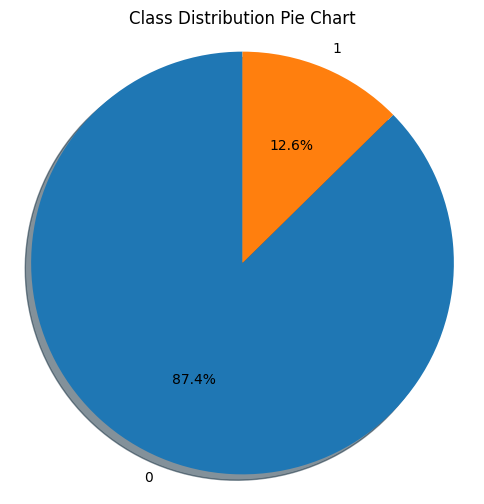

In [62]:
import matplotlib.pyplot as plt

# Count of each class
class_distribution = df['Target'].value_counts()
print(class_distribution)

# Proportion of each class in %
class_proportions = df['Target'].value_counts(normalize=True) * 100
print("\nClass Proportions (%):")
print(class_proportions)

# Prepare labels and sizes for pie chart
labels = class_distribution.index
sizes = class_distribution.values

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, shadow=True)
plt.title('Class Distribution Pie Chart')
plt.axis('equal')  # Make circle
plt.show()


In [ ]:
import pandas as pd


df['message'] = df['message'].astype(str)


df['char_count'] = df['message'].apply(len)


df['word_count'] = df['message'].apply(lambda x: len(x.split()))


import re
df['sentence_count'] = df['message'].apply(lambda x: len(re.split(r'[.!?]+', x)) - 1)

df.head()


,Target,message,char_count,word_count,sentence_count
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1
3,0,U dun say so early hor... U c already then say...,49,11,2
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0


In [ ]:
df['message'] = df['message'].astype(str).str.lower()
df[['message']].head()

,message
0,"go until jurong point, crazy.. available only ..."
1,ok lar... joking wif u oni...
2,free entry in 2 a wkly comp to win fa cup fina...
3,u dun say so early hor... u c already then say...
4,"nah i don't think he goes to usf, he lives aro..."


In [88]:

df['tokenized_message'] = df['message'].apply(word_tokenize)



In [91]:
df['tokenized_message'] = df['tokenized_message'].apply(lambda words: [w for w in words if w.isalnum()])


In [95]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
def remove_stopwords_punct(text):
    tokens = word_tokenize(text)               # tokenize
    tokens = [w for w in tokens if w.isalnum()] # remove punctuation
    tokens = [w for w in tokens if w.lower() not in stop_words]  # remove stopwords
    return ' '.join(tokens)
df['tokenized_message'] = df['message'].apply(remove_stopwords_punct)
df['clean_message'] = df['message'].apply(remove_stopwords_punct)

# Check
df[['message', 'clean_message']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,message,clean_message
0,"go until jurong point, crazy.. available only ...",go jurong point crazy available bugis n great ...
1,ok lar... joking wif u oni...,ok lar joking wif u oni
2,free entry in 2 a wkly comp to win fa cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,u dun say so early hor... u c already then say...,u dun say early hor u c already say
4,"nah i don't think he goes to usf, he lives aro...",nah think goes usf lives around though


In [97]:
df.head()

,Target,message,char_count,word_count,sentence_count,tokenized_message,clean_message
0,0,"go until jurong point, crazy.. available only ...",111,20,3,go jurong point crazy available bugis n great ...,go jurong point crazy available bugis n great ...
1,0,ok lar... joking wif u oni...,29,6,2,ok lar joking wif u oni,ok lar joking wif u oni
2,1,free entry in 2 a wkly comp to win fa cup fina...,155,28,1,free entry 2 wkly comp win fa cup final tkts 2...,free entry 2 wkly comp win fa cup final tkts 2...
3,0,u dun say so early hor... u c already then say...,49,11,2,u dun say early hor u c already say,u dun say early hor u c already say
4,0,"nah i don't think he goes to usf, he lives aro...",61,13,0,nah think goes usf lives around though,nah think goes usf lives around though


In [98]:

from nltk.stem import PorterStemmer, WordNetLemmatizer


nltk.download('wordnet')
nltk.download('omw-1.4')  



[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...


True

In [ ]:
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

stemmer = PorterStemmer()


df['clean_message'] = df['clean_message'].astype(str)


df['stemmed_tokens'] = df['clean_message'].apply(
    lambda text: [stemmer.stem(w) for w in word_tokenize(text) if w.isalnum()]
)


df['stemmed_message'] = df['stemmed_tokens'].apply(lambda tokens: ' '.join(tokens))


df[['clean_message', 'stemmed_tokens', 'stemmed_message']].head()


,clean_message,stemmed_tokens,stemmed_message
0,go jurong point crazy available bugis n great ...,"[go, jurong, point, crazi, avail, bugi, n, gre...",go jurong point crazi avail bugi n great world...
1,ok lar joking wif u oni,"[ok, lar, joke, wif, u, oni]",ok lar joke wif u oni
2,free entry 2 wkly comp win fa cup final tkts 2...,"[free, entri, 2, wkli, comp, win, fa, cup, fin...",free entri 2 wkli comp win fa cup final tkt 21...
3,u dun say early hor u c already say,"[u, dun, say, earli, hor, u, c, alreadi, say]",u dun say earli hor u c alreadi say
4,nah think goes usf lives around though,"[nah, think, goe, usf, live, around, though]",nah think goe usf live around though


In [ ]:
tfidf = TfidfVectorizer(
    max_features=3000,      
    stop_words='english',    
    ngram_range=(1,2)        
)
X = tfidf.fit_transform(df['stemmed_message'])
y = df['Target']

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
models = {
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "RandomForest": RandomForestClassifier(random_state=42)
}

results = {"Model": [], "Accuracy": [], "Precision": []}


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    
    results["Model"].append(name)
    results["Accuracy"].append(round(acc, 4))
    results["Precision"].append(round(prec, 4))


results_df = pd.DataFrame(results)
print(results_df)


best_model_index = results_df["Precision"].idxmax()
best_model_name = results_df.loc[best_model_index, "Model"]


best_model = models[best_model_name]

print(f"\n Best Model: {best_model_name}")

import pickle


with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)


with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)


           Model  Accuracy  Precision
0  MultinomialNB    0.9710     0.9915
1    BernoulliNB    0.9768     0.9840
2   RandomForest    0.9720     0.9915

✅ Best Model: MultinomialNB


In [ ]:
def transform_text(text):
    import string
    from nltk.corpus import stopwords
    from nltk.stem.porter import PorterStemmer
    import nltk
    nltk.data.path.append(r'D:\Internships\AI Arch technologies\SMS\nltk_data')  # your nltk_data path

    ps = PorterStemmer()
    
   
    text = text.lower()
    words = nltk.word_tokenize(text)
    
    
    words = [ps.stem(w) for w in words if w.isalnum() and w not in stopwords.words('english')]
    

    return " ".join(words)


In [ ]:

new_sms = "Congratulations! You won a free prize. Click here."
transformed_sms = transform_text(new_sms)
vector_input = tfidf.transform([transformed_sms])


In [ ]:
print("Transformed SMS:", transformed_sms)  
print("Vector shape:", vector_input.shape)  
print("Non-zero features:", vector_input.nnz)  


Transformed SMS: congratul free prize click
Vector shape: (1, 3000)
Non-zero features: 4


In [ ]:

transformed_sms = transform_text(new_sms)
vector_input = tfidf.transform([transformed_sms])
prediction = best_model.predict(vector_input)[0]

if prediction == 1:
    print("Spam")
else:
    print("Ham")


Spam


In [ ]:
import streamlit as st
import pickle


with open('vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open('best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)


def transform_text(text):
    import string
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem.porter import PorterStemmer
    nltk.data.path.append(r'D:\Internships\AI Arch technologies\SMS\nltk_data')  # your path
    
    ps = PorterStemmer()
    text = text.lower()
    words = nltk.word_tokenize(text)
    words = [ps.stem(w) for w in words if w.isalnum() and w not in stopwords.words('english')]
    return " ".join(words)


st.title("SMS Spam Classifier")

sms_input = st.text_area("Enter SMS message:")

if st.button("Predict"):
    transformed_sms = transform_text(sms_input)
    vector_input = tfidf.transform([transformed_sms])
    prediction = best_model.predict(vector_input)[0]
    
    if prediction == 1:
        st.error("Spam")
    else:
        st.success("Ham")


2026-01-06 02:54:47.314 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-06 02:54:47.320 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-06 02:54:47.337 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-06 02:54:47.346 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-06 02:54:47.353 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-06 02:54:47.358 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-06 02:54:47.363 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-06 02:54:47.373 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar